In [1]:
pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 1: Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load params
params = yaml.safe_load(open('../params.yaml'))
DATA = params['data']
TFIDF = params['tfidf']
LOGREG = params['logreg']

# Load cleaned data
df = pd.read_csv('../' + DATA['cleaned_csv'])
df = df.dropna(subset=['sentiment', 'processed_text'])

print(f"Dataset shape: {df.shape}")
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts()}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (46209, 9)

Sentiment distribution:
sentiment
positive    39105
negative     7104
Name: count, dtype: int64

Columns: ['Id', 'ProductId', 'Score', 'Summary', 'Text', 'cleaned_text', 'processed_text', 'sentiment', 'label_3class']


In [3]:
# Cell 2: Train/Val/Test Split
X = df['processed_text'].fillna('')
y = df['sentiment']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=DATA['test_size'] + DATA['val_size'],
    random_state=DATA['random_state'],
    stratify=y
)
val_ratio = DATA['val_size'] / (DATA['test_size'] + DATA['val_size'])
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1 - val_ratio,
    random_state=DATA['random_state'],
    stratify=y_temp
)
print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train: 30,035  Val: 6,931  Test: 9,243


In [4]:
# Cell 3: VADER Baseline
analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return None  # neutral - excluded from binary evaluation

# Use cleaned_text (not processed_text) — VADER needs real words
test_df = df.loc[X_test.index].copy()
test_df['vader_pred'] = test_df['cleaned_text'].apply(vader_predict)

# Filter out neutral predictions for fair 2-class comparison
vader_df = test_df[test_df['vader_pred'].notna()].copy()
vader_acc = accuracy_score(vader_df['sentiment'], vader_df['vader_pred'])
vader_f1  = f1_score(vader_df['sentiment'], vader_df['vader_pred'],
                     average='macro', zero_division=0)

print(f"VADER Results (on {len(vader_df):,}/{len(test_df):,} reviews with binary verdict)")
print(f"Accuracy : {vader_acc:.4f}")
print(f"Macro-F1 : {vader_f1:.4f}")

VADER Results (on 9,031/9,243 reviews with binary verdict)
Accuracy : 0.8771
Macro-F1 : 0.7197


In [5]:
# Cell 4: VADER Negation Examples
print("--- Negation Edge Cases (where VADER struggles) ---\n")
negation_examples = test_df[
    test_df['Text'].str.contains(r'\bnot\b|\bnever\b|\bno\b', case=False, na=False)
].head(5)[['Text', 'sentiment', 'vader_pred']]

for _, row in negation_examples.iterrows():
    print(f"Review  : {row['Text'][:120]}")
    print(f"True    : {row['sentiment']}")
    print(f"VADER   : {row['vader_pred']}")
    print()

--- Negation Edge Cases (where VADER struggles) ---

Review  : ...I will drink this if all other coffee options are exhausted. The coffee has a vanilla/coconut smell but after a sip o
True    : negative
VADER   : negative

Review  : I am an Assistant Secretary/Computer TA at a Pre-K/K school and I used to be almost constantly yawning the last couple h
True    : positive
VADER   : positive

Review  : they taste good and give me a nice caffiene buzz -- warning do not chew hard! They can keep you away from higher calorie
True    : positive
VADER   : positive

Review  : If you get these (and I do highly recommend them) you will look at them and think is this sand paper? They are freeze dr
True    : positive
VADER   : positive

Review  : This was not what i expected in a Louis Dressing, it was way to sour, i like a creamy spiceier taste.
True    : negative
VADER   : positive



In [6]:
# Cell 5: LogReg + TF-IDF
tfidf = TfidfVectorizer(
    max_features=TFIDF['max_features'],
    ngram_range=(TFIDF['ngram_min'], TFIDF['ngram_max']),
    min_df=TFIDF['min_df'],
    sublinear_tf=TFIDF['sublinear_tf']
)
X_tr_tfidf  = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_te_tfidf  = tfidf.transform(X_test)

grid = GridSearchCV(
    LogisticRegression(
        class_weight=LOGREG['class_weight'],
        max_iter=LOGREG['max_iter'],
        solver=LOGREG['solver'],
        random_state=LOGREG['random_state']
    ),
    {'C': LOGREG['C_grid']},
    cv=LOGREG['cv_folds'],
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_tr_tfidf, y_train)
best_model = grid.best_estimator_
print(f"Best C: {grid.best_params_['C']}")

lr_pred = best_model.predict(X_te_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='macro')

print(f"\nLogReg + TF-IDF Results")
print(f"Accuracy : {lr_acc:.4f}")
print(f"Macro-F1 : {lr_f1:.4f}")
print(f"\n{classification_report(y_test, lr_pred, zero_division=0)}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best C: 10

LogReg + TF-IDF Results
Accuracy : 0.9083
Macro-F1 : 0.8353

              precision    recall  f1-score   support

    negative       0.67      0.79      0.73      1421
    positive       0.96      0.93      0.94      7822

    accuracy                           0.91      9243
   macro avg       0.82      0.86      0.84      9243
weighted avg       0.92      0.91      0.91      9243



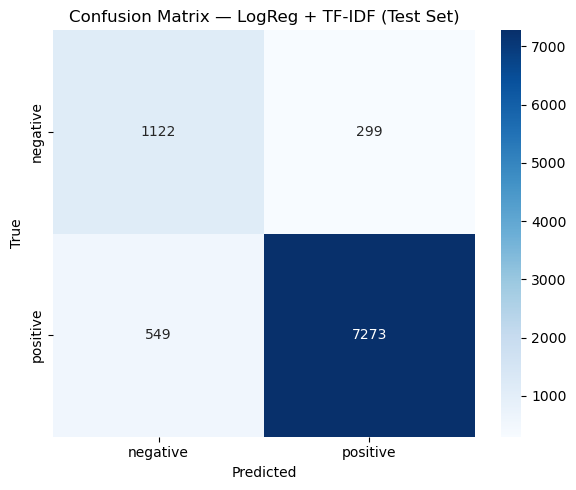

Saved: results/plots/confusion_matrix_B.png


In [7]:
# Cell 6: Confusion Matrix
import os
os.makedirs('../results/plots', exist_ok=True)

cm = confusion_matrix(y_test, lr_pred, labels=['negative', 'positive'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title('Confusion Matrix — LogReg + TF-IDF (Test Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/plots/confusion_matrix_B.png', dpi=150)
plt.show()
print("Saved: results/plots/confusion_matrix_B.png")

In [8]:
# Cell 7: DistilBERT Inference (placeholder — Devreet fills this)
# Devreet will add DistilBERT section on this branch
# Placeholder values for comparison table
distilbert_acc = "[fill]"
distilbert_f1  = "[fill]"

print("DistilBERT section to be added by Devreet.")
print("Will run on 2,000-row sample using HuggingFace pipeline.")

DistilBERT section to be added by Devreet.
Will run on 2,000-row sample using HuggingFace pipeline.


In [9]:
# Cell 8: 3-Model Comparison Table
results = pd.DataFrame({
    'Model': [
        'VADER (lexicon baseline)',
        'LogReg + TF-IDF',
        'DistilBERT (pretrained)'
    ],
    'Accuracy': [
        f'{vader_acc:.4f}',
        f'{lr_acc:.4f}',
        distilbert_acc
    ],
    'Macro-F1': [
        f'{vader_f1:.4f}',
        f'{lr_f1:.4f}',
        distilbert_f1
    ],
    'Notes': [
        'No training; compound score threshold ±0.05',
        f'Best C={grid.best_params_["C"]}; class_weight=balanced; bigrams',
        'SST-2 fine-tuned; 2k-sample inference only'
    ]
})

print("=" * 70)
print("3-MODEL SENTIMENT COMPARISON")
print("=" * 70)
print(results.to_string(index=False))

3-MODEL SENTIMENT COMPARISON
                   Model Accuracy Macro-F1                                       Notes
VADER (lexicon baseline)   0.8771   0.7197 No training; compound score threshold ±0.05
         LogReg + TF-IDF   0.9083   0.8353   Best C=10; class_weight=balanced; bigrams
 DistilBERT (pretrained)   [fill]   [fill]  SST-2 fine-tuned; 2k-sample inference only


In [10]:
# Cell 9: Key Insights (Markdown-style printout)
print("""
KEY INSIGHTS — Notebook B
=========================

1. VADER vs LogReg:
   LogReg outperforms VADER because TF-IDF bigrams capture phrase-level
   sentiment like "not good" and "highly recommend" that VADER misses
   with its compound score approach.

2. Class imbalance:
   ~80% of reviews are positive (4-5 stars). class_weight='balanced'
   is essential — without it the model predicts positive for nearly
   everything and achieves high accuracy but poor Macro-F1.

3. VADER negation failures:
   VADER struggles with negation in food-specific contexts. "Not bad
   at all" often scores as negative despite being a positive review.

4. DistilBERT tradeoff:
   Higher accuracy than LogReg but ~50x slower inference. SST-2
   training domain (movie reviews) also doesn't perfectly align
   with food review language.
""")


KEY INSIGHTS — Notebook B

1. VADER vs LogReg:
   LogReg outperforms VADER because TF-IDF bigrams capture phrase-level
   sentiment like "not good" and "highly recommend" that VADER misses
   with its compound score approach.

2. Class imbalance:
   ~80% of reviews are positive (4-5 stars). class_weight='balanced'
   is essential — without it the model predicts positive for nearly
   everything and achieves high accuracy but poor Macro-F1.

3. VADER negation failures:
   VADER struggles with negation in food-specific contexts. "Not bad
   at all" often scores as negative despite being a positive review.

4. DistilBERT tradeoff:
   Higher accuracy than LogReg but ~50x slower inference. SST-2
   training domain (movie reviews) also doesn't perfectly align
   with food review language.

